<a href="https://colab.research.google.com/github/ncrowder/maven/blob/main/maven_drill_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('https://maven-datasets.s3.us-east-1.amazonaws.com/Data+Drills/marathon-data.csv')

In [ ]:
df.head()

,age,gender,split,final
0,33,M,01:05:38,02:08:51
1,32,M,01:06:26,02:09:28
2,31,M,01:06:49,02:10:42
3,38,M,01:06:16,02:13:45
4,31,M,01:06:32,02:13:59


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37250 entries, 0 to 37249
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   age     37250 non-null  int64 
 1   gender  37250 non-null  object
 2   split   37250 non-null  object
 3   final   37250 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.1+ MB


In [ ]:
time_cols = ['split','final']

In [ ]:
print(df[time_cols].dtypes)

for col in time_cols:
    print(col, type(df[col].dropna().iloc[0]))

split    object
final    object
dtype: object
split <class 'str'>
final <class 'str'>


In [ ]:
time_cols = ['split','final']
df[time_cols] = df[time_cols].apply(pd.to_timedelta)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37250 entries, 0 to 37249
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype          
---  ------  --------------  -----          
 0   age     37250 non-null  int64          
 1   gender  37250 non-null  object         
 2   split   37250 non-null  timedelta64[ns]
 3   final   37250 non-null  timedelta64[ns]
dtypes: int64(1), object(1), timedelta64[ns](2)
memory usage: 1.1+ MB


In [ ]:
df

,age,gender,split,final
0,33,M,0 days 01:05:38,0 days 02:08:51
1,32,M,0 days 01:06:26,0 days 02:09:28
2,31,M,0 days 01:06:49,0 days 02:10:42
3,38,M,0 days 01:06:16,0 days 02:13:45
4,31,M,0 days 01:06:32,0 days 02:13:59
...,...,...,...,...
37245,18,M,0 days 04:24:24,0 days 09:32:57
37246,36,M,0 days 04:35:43,0 days 09:33:28
37247,51,M,0 days 04:22:35,0 days 09:33:40
37248,55,W,0 days 04:58:06,0 days 10:00:40


In [ ]:
bins = [
    pd.Timedelta(hours=0),
    pd.Timedelta(hours=3),
    pd.Timedelta(hours=3.5),
    pd.Timedelta(hours=4),
    pd.Timedelta(hours=4.5),
    pd.Timedelta(hours=5),
    pd.Timedelta(hours=5.5),
    pd.Timedelta(hours=6),
    pd.Timedelta.max
]

labels = [
    '0-3',
    '3-3.5',
    '3.5-4',
    '4-4.5',
    '4.5-5',
    '5-5.5',
    '5.5-6',
    '6+'
]

df['final_band'] = pd.cut(
    df['final'],
    bins=bins,
    labels=labels
)

In [ ]:
df

,age,gender,split,final,final_band
0,33,M,0 days 01:05:38,0 days 02:08:51,0-3
1,32,M,0 days 01:06:26,0 days 02:09:28,0-3
2,31,M,0 days 01:06:49,0 days 02:10:42,0-3
3,38,M,0 days 01:06:16,0 days 02:13:45,0-3
4,31,M,0 days 01:06:32,0 days 02:13:59,0-3
...,...,...,...,...,...
37245,18,M,0 days 04:24:24,0 days 09:32:57,6+
37246,36,M,0 days 04:35:43,0 days 09:33:28,6+
37247,51,M,0 days 04:22:35,0 days 09:33:40,6+
37248,55,W,0 days 04:58:06,0 days 10:00:40,6+


In [ ]:
df.final_band.value_counts(normalize=True).sort_index()

,proportion
final_band,
0-3,0.025933
3-3.5,0.081638
3.5-4,0.130980
4-4.5,0.171034
4.5-5,0.181638
5-5.5,0.169879
5.5-6,0.112134
6+,0.126765


<Axes: xlabel='final_band'>

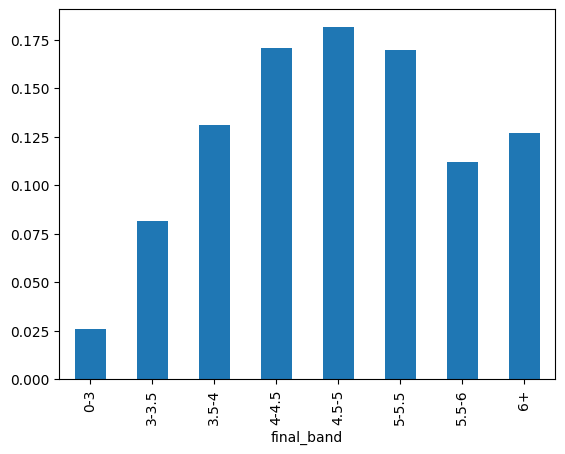

In [ ]:
df.final_band.value_counts(normalize=True).sort_index().plot.bar()

<Axes: >

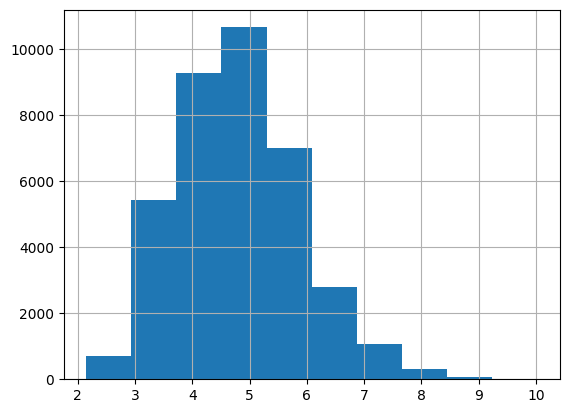

In [ ]:
df['final_hours'] = df['final'].dt.total_seconds() / 3600
df['final_hours'].hist()

<Axes: title={'center': 'final_hours'}, xlabel='gender'>

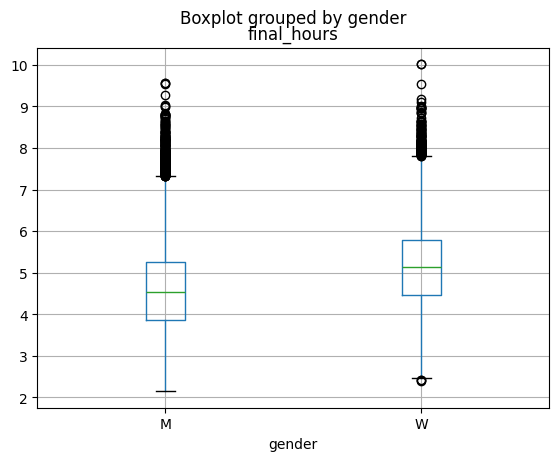

In [ ]:
df.boxplot(column='final_hours', by='gender')

array([<Axes: title={'center': 'M'}>, <Axes: title={'center': 'W'}>],
      dtype=object)

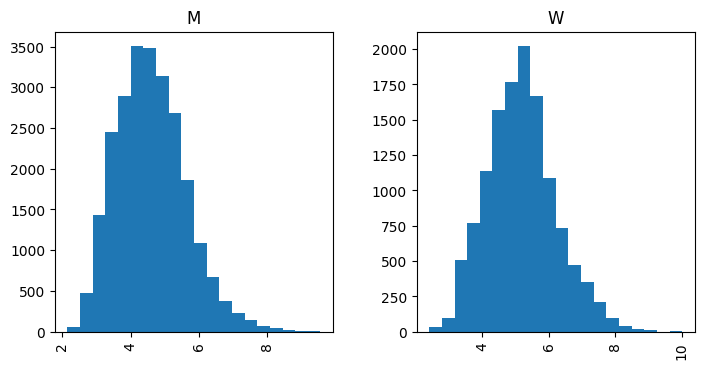

In [ ]:
df.hist(
    column='final_hours',
    by='gender',
    bins=20,
    figsize=(8,4)
)

<Axes: xlabel='final_band'>

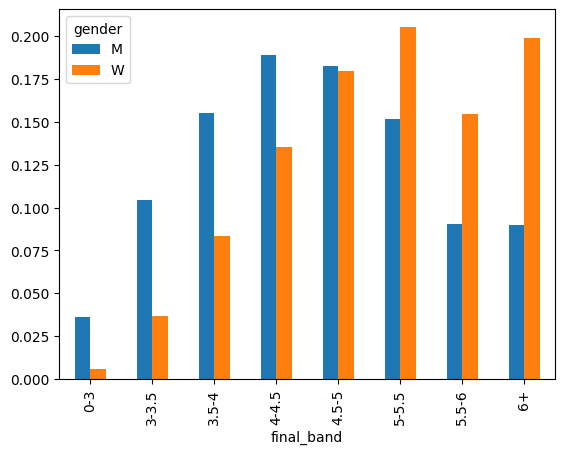

In [ ]:
pd.crosstab(
    df['final_band'],
    df['gender'],
    normalize='columns'
).plot.bar()

In [ ]:
pd.crosstab(
    df['final_band'],
    df['gender'],
    normalize='columns'
)

gender,M,W
final_band,,
0-3,0.036165,0.005880
3-3.5,0.104642,0.036551
3.5-4,0.155362,0.083194
4-4.5,0.189256,0.135320
4.5-5,0.182566,0.179817
5-5.5,0.151713,0.205483
5.5-6,0.090493,0.154549
6+,0.089803,0.199205


<Axes: xlabel='final_band'>

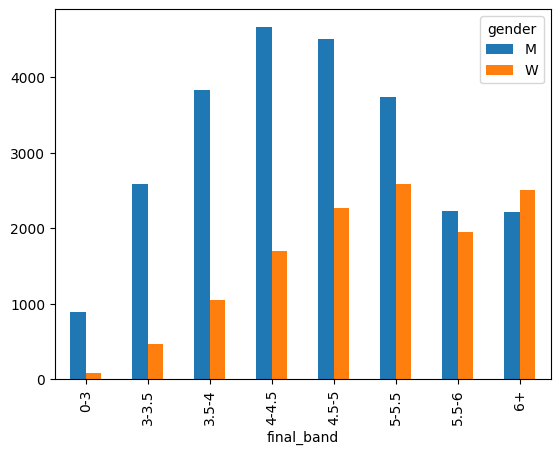

In [ ]:
(
    df.groupby(['final_band', 'gender'],observed=False)
      .size()
      .unstack()
      .plot.bar()
)

In [ ]:
df.groupby(['final_band', 'gender'],observed=False).size().unstack()

gender,M,W
final_band,,
0-3,892,74
3-3.5,2581,460
3.5-4,3832,1047
4-4.5,4668,1703
4.5-5,4503,2263
5-5.5,3742,2586
5.5-6,2232,1945
6+,2215,2507


In [ ]:
df.groupby(['final_band', 'gender'],observed=False).size()

final_band  gender
0-3         M          892
            W           74
3-3.5       M         2581
            W          460
3.5-4       M         3832
            W         1047
4-4.5       M         4668
            W         1703
4.5-5       M         4503
            W         2263
5-5.5       M         3742
            W         2586
5.5-6       M         2232
            W         1945
6+          M         2215
            W         2507
dtype: int64